In [65]:
!pip install -q transformers datasets evaluate accelerate scikit-learn seaborn matplotlib

In [69]:
import numpy as np
import pandas as pd
import evaluate
import joblib
import torch

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
set_seed(42)

In [71]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

Saving data.csv to data (2).csv


In [72]:
df.head()

,query,Category,Topic
0,What is A* Search? Explain the stages of A* Se...,AI,A* Search
1,What are real-world applications of modern AI ...,AI,AI Applications
2,Compare symbolic AI and statistical AI.,AI,AI Approaches
3,Discuss ethical issues in Artificial Intellige...,AI,AI Ethics
4,Explain transparency in AI systems.,AI,AI Ethics


In [73]:
df = df.drop_duplicates(subset=["query"])

df = df.dropna()

df = df[df["Category"] != "Category"]

df.reset_index(drop=True, inplace=True)

print(df.shape)

(1501, 3)


In [74]:
print(df["Category"].value_counts())

Category
NLP    291
AI     284
ML     275
RL     263
CV     235
DL     153
Name: count, dtype: int64


In [75]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["Category"])

joblib.dump(label_encoder, "label_encoder.pkl")

print(label_encoder.classes_)

['AI' 'CV' 'DL' 'ML' 'NLP' 'RL']


Split Dataset

In [76]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

1200 150 151


In [77]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [78]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

TOKENIZATION


In [79]:
def tokenize(batch):
    return tokenizer(
        batch["query"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

APPLY **TOKENIZATION**

In [80]:
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/151 [00:00<?, ? examples/s]

In [81]:
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

In [82]:
cols = ["query", "Category", "Topic", "__index_level_0__"]

for c in cols:
    if c in train_dataset.column_names:
        train_dataset = train_dataset.remove_columns(c)

for c in cols:
    if c in val_dataset.column_names:
        val_dataset = val_dataset.remove_columns(c)

for c in cols:
    if c in test_dataset.column_names:
        test_dataset = test_dataset.remove_columns(c)

In [83]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [84]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [85]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=torch.cuda.is_available()
)

In [86]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [87]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.641272,1.467939,0.513333,0.542531,0.513333,0.464009
2,1.329279,1.177851,0.640000,0.599906,0.640000,0.608946
3,1.109708,1.079480,0.673333,0.617115,0.673333,0.638298


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=225, training_loss=1.360086398654514, metrics={'train_runtime': 45.9151, 'train_samples_per_second': 78.406, 'train_steps_per_second': 4.9, 'total_flos': 119229163315200.0, 'train_loss': 1.360086398654514, 'epoch': 3.0})

In [88]:
results = trainer.evaluate(test_dataset)

print(results)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.109708,1.051105,3,0.708609,0.641916,0.708609,0.669733


{'eval_loss': 1.0511047840118408, 'eval_accuracy': 0.7086092715231788, 'eval_precision': 0.6419160616180484, 'eval_recall': 0.7086092715231788, 'eval_f1': 0.6697331767306813}


In [89]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [90]:
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

          AI       0.79      0.90      0.84        29
          CV       0.71      0.74      0.72        23
          DL       0.00      0.00      0.00        15
          ML       0.68      0.68      0.68        28
         NLP       0.74      0.69      0.71        29
          RL       0.64      0.93      0.76        27

    accuracy                           0.71       151
   macro avg       0.59      0.65      0.62       151
weighted avg       0.64      0.71      0.67       151



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


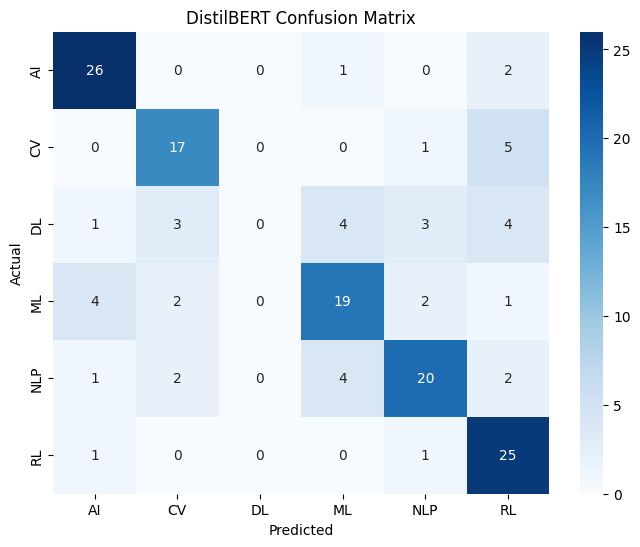

In [91]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.show()

In [92]:
model.save_pretrained("distilbert_model")

tokenizer.save_pretrained("distilbert_model")

joblib.dump(label_encoder, "label_encoder.pkl")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['label_encoder.pkl']